**Problem 2**

In [62]:
nSamples = 100
p = 0.97825 #solved in part 2a

pA = 0.85
pB = 0.95
pC = 0.90

sum_system = 0

for _ in range(nSamples):
    A = 1 if random.random() < pA else 0
    B = 1 if random.random() < pB else 0
    C = 1 if random.random() < pC else 0

    X_system = (1 - (1 - A) * (1 - (B * C)))
    sum_system += X_system

p_hat = sum_system / nSamples
print("p_hat:", p_hat)

err = (p_hat-p)/p
print("Relative error:", err) #relative error

p_hat: 0.97
Relative error: -0.00843342703807818


**Problem 3**

Estimated E[T]: 10.088904113485553
Minimum T: 7.842400912645893
Maximum T: 11.886213572482673


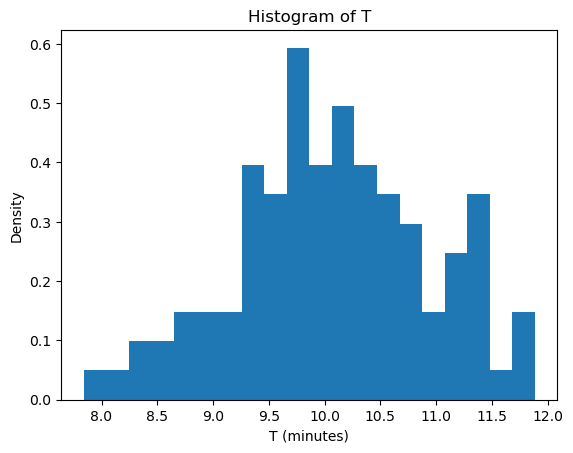

P(Eggs critical): 0.36
P(Toast critical): 0.31
P(Bacon critical): 0.33


In [5]:
import random
import matplotlib.pyplot as plt

nSamples = 100
sum_T = 0
T_values = []
Teggs_list = []
Ttoast_list = []
Tbacon_list = []

for _ in range(nSamples):
    # record T, Teggs, Ttoast, Tbacon for each instance
    # Teggs: A1 + A2 + A3
    A1 = random.uniform(2, 4)
    A2 = random.uniform(2, 4)
    A3 = random.uniform(2, 4)
    Teggs = A1 + A2 + A3
    # Ttoast: B1 + B2 
    B1 = random.uniform(3, 6)
    B2 = random.uniform(3, 6)
    Ttoast = B1 + B2
    # Tbacon: C1
    Tbacon = random.uniform(6, 12)

    # T = max(Teggs) + max(Ttoast) + max(Tbacon)
    T = max(Teggs, Ttoast, Tbacon)

    sum_T += T 
    # list for all instances
    T_values.append(T) 
    Teggs_list.append(Teggs)
    Ttoast_list.append(Ttoast)
    Tbacon_list.append(Tbacon)

# estimates
T_hat = sum_T / nSamples
T_min = min(T_values)
T_max = max(T_values)

print("Estimated E[T]:", T_hat)
print("Minimum T:", T_min)
print("Maximum T:", T_max)

# Histogram
plt.hist(T_values, bins=20, density=True)
plt.xlabel("T (minutes)")
plt.ylabel("Density")
plt.title("Histogram of T")
plt.show()

eggs_critical = 0
toast_critical = 0
bacon_critical = 0

for i in range(nSamples): #critical if path took longest
    if Teggs_list[i] >= Ttoast_list[i] and Teggs_list[i] >= Tbacon_list[i]:
        eggs_critical += 1
    elif Ttoast_list[i] >= Teggs_list[i] and Ttoast_list[i] >= Tbacon_list[i]:
        toast_critical += 1
    else:
        bacon_critical += 1

print("P(Eggs critical):", eggs_critical / nSamples)
print("P(Toast critical):", toast_critical / nSamples)
print("P(Bacon critical):", bacon_critical / nSamples)

In [88]:
# chat gpt:

import random
import matplotlib.pyplot as plt

def U(a, b):
    return random.uniform(a, b)

n = 100
T, eggs, toast, bacon = [], [], [], []

for _ in range(n):
    Teggs = U(2,4) + U(2,4) + U(2,4)
    Ttoast = U(3,6) + U(3,6)
    Tbacon = U(6,12)
    
    eggs.append(Teggs)
    toast.append(Ttoast)
    bacon.append(Tbacon)
    T.append(max(Teggs, Ttoast, Tbacon))

print(sum(T)/n, min(T), max(T))


from collections import Counter

critical = []
for i in range(n):
    times = {'eggs': eggs[i], 'toast': toast[i], 'bacon': bacon[i]}
    critical.append(max(times, key=times.get))
 
pmf = Counter(critical)
{key: val/n for key, val in pmf.items()}

10.12854507494128 7.865433200130829 11.899250466964993


{'bacon': 0.43, 'toast': 0.3, 'eggs': 0.27}